In [66]:
!pip install ultralytics

import os
import shutil
import xml.etree.ElementTree as ET
import yaml
from ultralytics import YOLO

In [67]:
base_dir = '/content/parkir'
dest_img_dir = '/content/dataset/train/images'

os.makedirs(dest_img_dir, exist_ok=True)

count = 0
for r, d, files in os.walk(base_dir):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            shutil.copy(os.path.join(r, f), os.path.join(dest_img_dir, f))
            count += 1

print(f"{count} gambar pindah ke folder training.")

30 gambar pindah ke folder training.


In [68]:
xml_path = [os.path.join(r, f) for r, d, files in os.walk('/content/parkir') for f in files if f.endswith('.xml')][0]
root = ET.parse(xml_path).getroot()
class_mapping = {'free_parking_space': 0, 'not_free_parking_space': 1, 'partially_free_parking_space': 1}

for image in root.findall('image'):
    name = os.path.basename(image.get('name'))

    if os.path.exists(os.path.join('/content/dataset/train/images', name)):
        txt_path = os.path.join('/content/dataset/train/labels', os.path.splitext(name)[0] + '.txt')
        w, h = float(image.get('width')), float(image.get('height'))

        with open(txt_path, 'w') as f:
            for poly in image.findall('polygon'):
                label = poly.get('label')
                if label in class_mapping:
                    points = [float(p) for pair in poly.get('points').split(';') for p in pair.split(',')]
                    xs, ys = points[0::2], points[1::2]
                    x1, x2, y1, y2 = min(xs), max(xs), min(ys), max(ys)

                    xc, yc = ((x1 + x2) / 2) / w, ((y1 + y2) / 2) / h
                    bw, bh = (x2 - x1) / w, (y2 - y1) / h
                    f.write(f"{class_mapping[label]} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

print("Berhasil membuat label ")

Berhasil membuat label 


In [69]:
yaml_data = {
    'path': '/content/dataset',
    'train': 'train/images',
    'val': 'train/images',
    'names': {v: k for k, v in class_mapping.items()}
}
with open('/content/dataset/data.yaml', 'w') as f:
    yaml.dump(yaml_data, f)

print("File data.yaml telah dibuat.")

File data.yaml telah dibuat.


In [70]:
model = YOLO('yolov8n.pt')
model.train(data='/content/dataset/data.yaml', epochs=50, imgsz=640)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f3a125d97c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [71]:
results = model.predict(source='/content/dataset/train/images/', conf=0.25, save=True)

print("Prediksi selesai")


image 1/30 /content/dataset/train/images/0.png: 352x640 10 free_parking_spaces, 18 partially_free_parking_spaces, 6.8ms
image 2/30 /content/dataset/train/images/1.png: 480x640 6 free_parking_spaces, 35 partially_free_parking_spaces, 7.1ms
image 3/30 /content/dataset/train/images/10.png: 480x640 5 free_parking_spaces, 14 partially_free_parking_spaces, 6.2ms
image 4/30 /content/dataset/train/images/11.png: 512x640 5 free_parking_spaces, 33 partially_free_parking_spaces, 7.7ms
image 5/30 /content/dataset/train/images/12.png: 384x640 24 free_parking_spaces, 12 partially_free_parking_spaces, 9.8ms
image 6/30 /content/dataset/train/images/13.png: 384x640 3 free_parking_spaces, 29 partially_free_parking_spaces, 6.4ms
image 7/30 /content/dataset/train/images/14.png: 384x640 6 partially_free_parking_spaces, 6.2ms
image 8/30 /content/dataset/train/images/15.png: 448x640 13 free_parking_spaces, 22 partially_free_parking_spaces, 11.7ms
image 9/30 /content/dataset/train/images/17.png: 640x640 1 fr

Mencari gambar /content/runs/detect/predict-2
🖼️ Menampilkan: 10.jpg


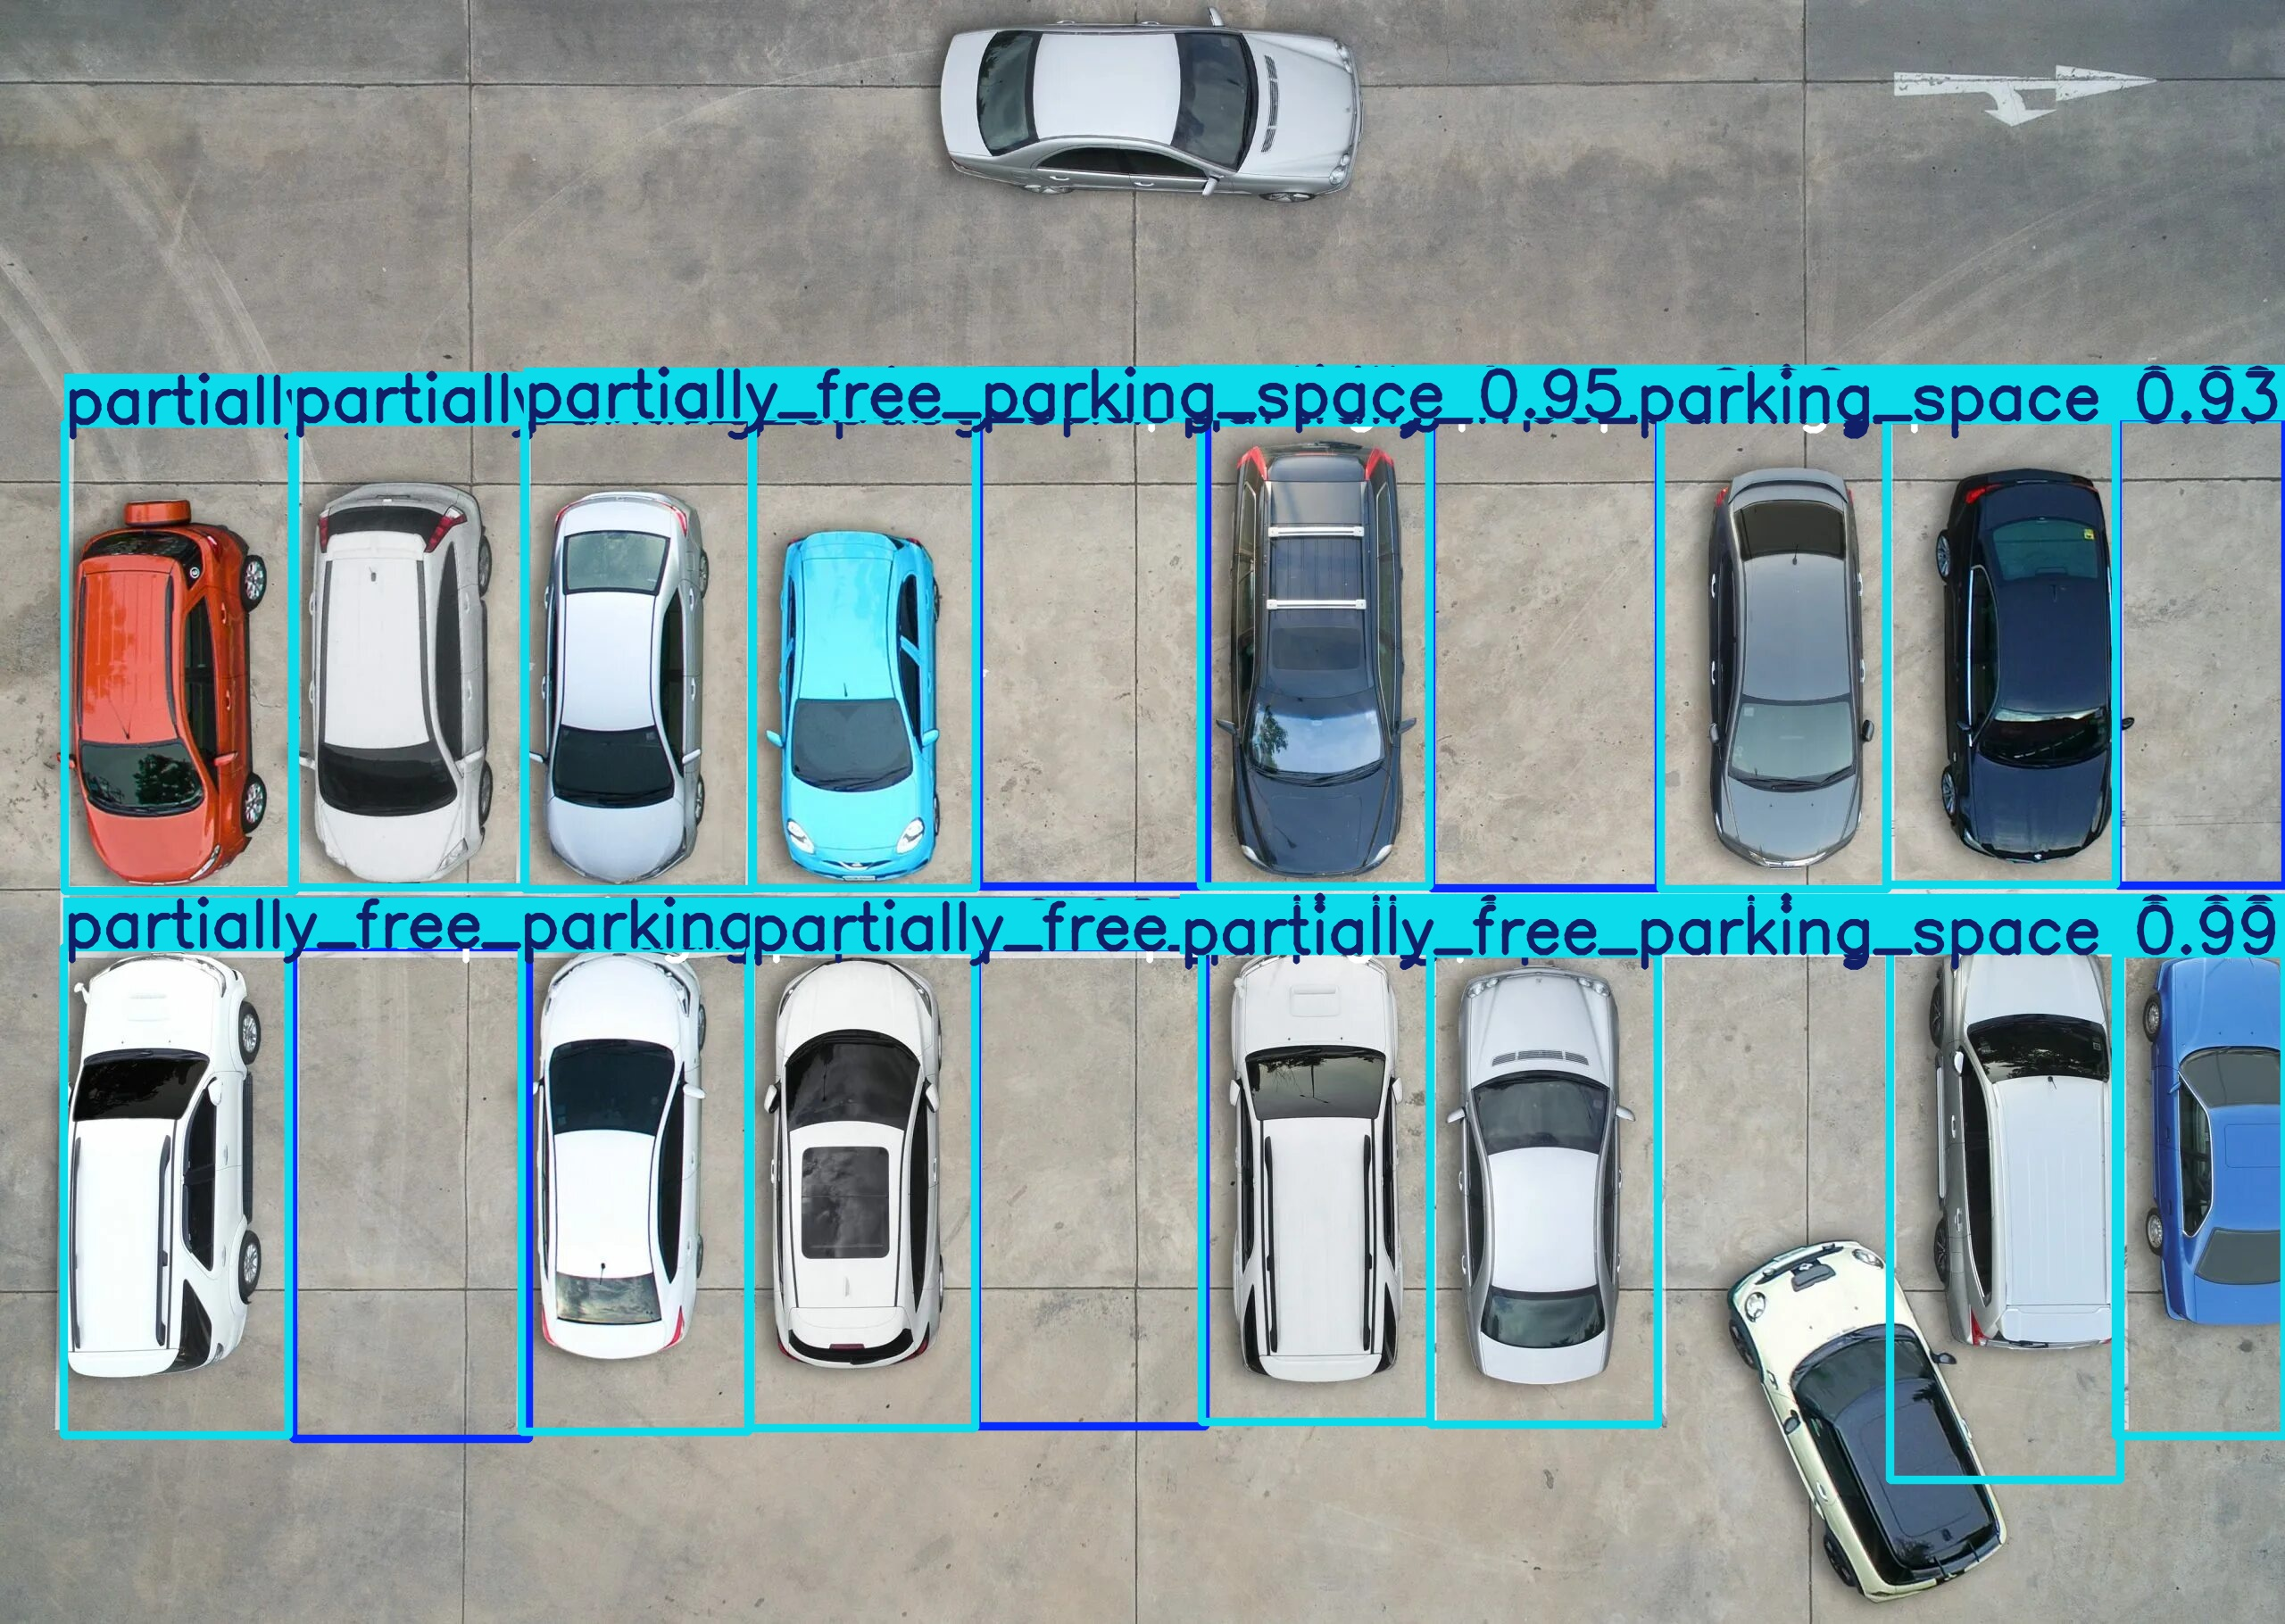

🖼️ Menampilkan: 4.jpg


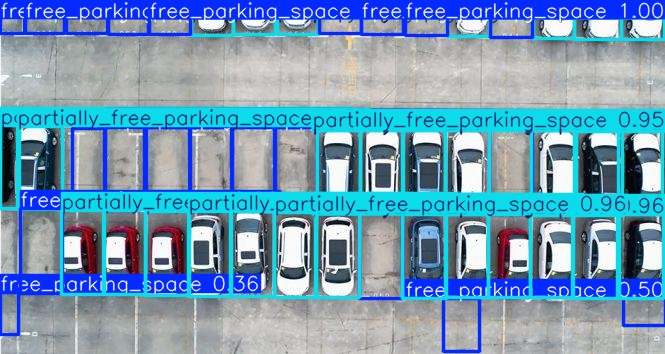

🖼️ Menampilkan: 11.jpg


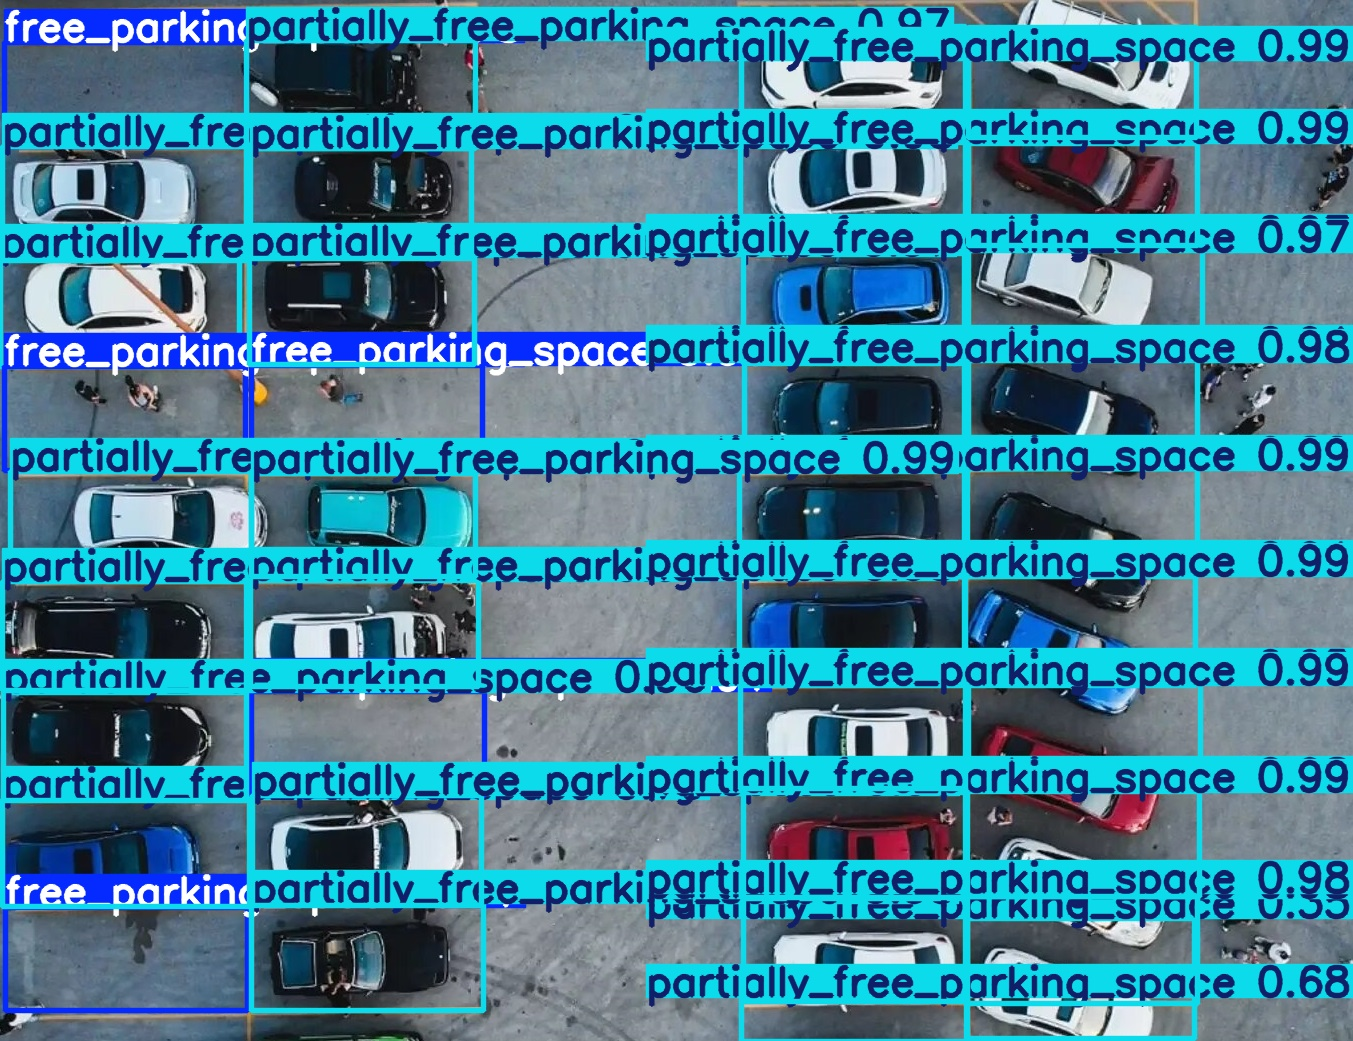

In [72]:
import glob
import os
from IPython.display import Image, display

semua_folder_prediksi = glob.glob('/content/runs/detect/predict*')

if not semua_folder_prediksi:
    print("Belum ada folder")
else:
    folder_terbaru = max(semua_folder_prediksi, key=os.path.getctime)
    print(f"Mencari gambar {folder_terbaru}")

    gambar_hasil = glob.glob(os.path.join(folder_terbaru, '*.*'))
    gambar_hasil = [img for img in gambar_hasil if img.endswith(('.png', '.jpg', '.jpeg'))]

    if not gambar_hasil:
        print("gambar kosong")
    else:
        for image_path in gambar_hasil[:3]:
            print(f"🖼️ Menampilkan: {os.path.basename(image_path)}")
            display(Image(filename=image_path))